In [12]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

import plotting
import data_extraction as da
scores_df = pd.read_parquet(os.path.join('data', 'subtitles_wer_scores.parquet'))
# TODO: add word/segment count to weighting

[nltk_data] Downloading package stopwords to /home/raine-
[nltk_data]     bianchini/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/raine-
[nltk_data]     bianchini/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [25]:
import numpy as np

In [30]:
txt_df = pd.read_parquet(da.cleaned_dataset_fp)
txt_df['char_len'] = txt_df.text.str.len()
movie_len_df = txt_df.groupby('movie').char_len.sum().reset_index()
results_df = movie_len_df.merge(scores_df, how='left', on='movie')
np.average(results_df.wer.values, axis=0, weights=results_df.char_len.values)

np.float64(0.3519636295700979)

In [8]:
scores_df.sort_values('wer', ascending=False).iloc[:20]

,movie,cer,wer
89,Bob Marley One Love,0.541827,0.673849
97,Beasts Of The Southern Wild,0.621675,0.667889
473,Paranormal Activity The Marked Ones,0.542474,0.648888
272,Beyond The Black Rainbow,0.589364,0.647210
545,Monkey Man,0.566698,0.636518
176,Everything Everywhere All At Once,0.509224,0.632810
467,In The Heights,0.567383,0.614353
315,John Wick,0.524399,0.602392
317,Mandy,0.556544,0.599362
10,Dawn Of The Planet Of The Apes,0.540725,0.597271


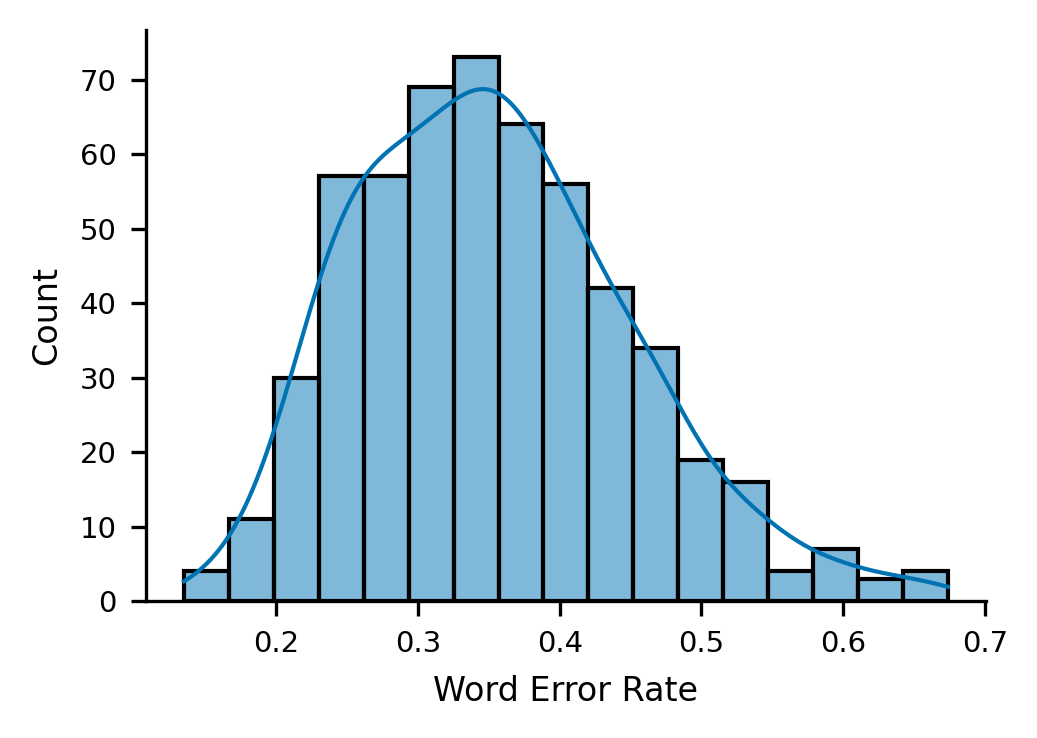

In [9]:
sns.histplot(scores_df.wer, kde=True)
plt.xlabel('Word Error Rate')
plt.tight_layout()
sns.despine()
plotting.savefig('Subtitles WER Hist')

In [10]:
scores_df.sort_values('wer', ascending=True).iloc[:10]

,movie,cer,wer
331,The Confirmation,0.103293,0.134884
519,Generation Wealth,0.120796,0.151983
114,The Grand Budapest Hotel,0.113292,0.158081
350,Rbg,0.139126,0.162462
351,Ex Machina,0.136288,0.172567
441,The Gospel According To Andre,0.128946,0.174849
402,Dater'S Handbook,0.133906,0.177177
191,Anatomy Of A Fall,0.140711,0.178299
510,Kinds Of Kindness,0.152258,0.184541
197,Holy Flying Circus,0.133530,0.186491
